## MeanDiff CAV 

In [45]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import clip
from sklearn.metrics.pairwise import cosine_similarity
from data_loading import load_sun_data
import torchvision.models as models
from torchvision import transforms as trn
import torch.nn as nn
from tqdm import tqdm
from dataloaders import create_sun_dataloader

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Używane urządzenie: {DEVICE}")

Używane urządzenie: cuda


In [13]:
def calculate_centroid_cav(features_matrix, concept_indices, background_indices=None):
    mean_concept = np.mean(features_matrix[concept_indices], axis=0)
    if background_indices is None:
        mean_background = np.mean(features_matrix, axis=0)
    else:
        mean_background = np.mean(features_matrix[background_indices], axis=0)
    cav = mean_concept - mean_background
    cav_normalized = cav / np.linalg.norm(cav)
    
    return cav_normalized

In [26]:
def get_cosine_similarity(vec1, vec2):
    sim = cosine_similarity(vec1.reshape(1, -1), vec2.reshape(1, -1))
    return sim[0][0]

def get_dot_product_similarity(vec1, vec2):
    return np.dot(vec1, vec2)

#### Wczytanie danych i ekstrakcja cech

In [ ]:
df_sun, attributes_list, attr_cols = load_sun_data(base_path='data/SUN/SUNAttributeDB', threshold=0.5)

print(f'Wczytano obrazy: {len(df_sun)}')
print(f'Liczba atrybutów: {len(attr_cols)}')

df_sun.head(3)

Wczytano obrazy: 14340
Liczba atrybutów: 102


,image_id,file_path,class_id,sailing/ boating,driving,biking,transporting things or people,sunbathing,vacationing/ touring,hiking,...,far-away horizon,no horizon,rugged scene,mostly vertical components,mostly horizontal components,symmetrical,cluttered space,scary,soothing,stressful
0,1,a/abbey/sun_aakbdcgfpksytcwj.jpg,a,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
1,2,a/abbey/sun_aaoktempcmudsvna.jpg,a,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,a/abbey/sun_abegcweqnetpdlrh.jpg,a,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
model_file = 'models/resnet18_places365.pth'
conv_model = models.resnet18(num_classes=365)
checkpoint = torch.load(model_file, map_location=lambda storage, loc: storage)
state_dict = {str.replace(k, 'module.', ''): v for k, v in checkpoint['state_dict'].items()}
conv_model.load_state_dict(state_dict)
conv_model.fc = nn.Identity() 
conv_model = conv_model.to(DEVICE).eval()

centre_crop = trn.Compose([
    trn.Resize((256, 256)),
    trn.CenterCrop(224),
    trn.ToTensor(),
    trn.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

clip_model, clip_preprocess = clip.load('ViT-B/32', device=DEVICE)
clip_model.eval()
print(f'Modele załadowane. Wymiar embeddingu CLIP: {clip_model.visual.output_dim}')


C:\Users\Admin\AppData\Local\Temp\ipykernel_51816\3260362360.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_file, map_location=lambda stor

Modele załadowane. Wymiar embeddingu CLIP: 512


In [11]:
dataloader_resnet = create_sun_dataloader(
    df=df_sun, img_dir='data/SUN/images/', transform=centre_crop,
    attr_cols=attr_cols, batch_size=32, num_workers=4
)

dataloader_clip = create_sun_dataloader(
    df=df_sun, img_dir='data/SUN/images/', transform=clip_preprocess,
    attr_cols=attr_cols, batch_size=64, num_workers=4)

In [18]:
features_conv = []
with torch.no_grad():
    for batch_imgs, _, _ in tqdm(dataloader_resnet, desc='ResNet18 features'):
        batch_imgs = batch_imgs.to(DEVICE)
        feats = conv_model(batch_imgs)
        features_conv.append(feats.cpu().numpy())
X_conv = np.concatenate(features_conv, axis=0)





















































































































ResNet18 features: 100%|██████████| 449/449 [00:35<00:00, 12.63it/s]


In [21]:
features_clip = []
with torch.no_grad():
    for batch_imgs, _, _ in tqdm(dataloader_clip, desc='CLIP features'):
        batch_imgs = batch_imgs.to(DEVICE)
        feats = clip_model.encode_image(batch_imgs).float()
        feats = feats / feats.norm(dim=1, keepdim=True)
        features_clip.append(feats.cpu().numpy())
X_clip = np.concatenate(features_clip, axis=0)

























































































CLIP features: 100%|██████████| 225/225 [00:45<00:00,  4.93it/s]


#### Wyznaczenie CAV dla relacji empirycznych

In [22]:
empirical_pairs = [
    ('research', 'enclosed area'),
    ('camping', 'open area'),
    ('medical activity', 'enclosed area'),
    ('gaming', 'enclosed area'),
    ('sand', 'natural light'),
    ('carpet', 'enclosed area')
]

In [30]:
results_empirical = []

In [31]:
for concept_a, concept_b in empirical_pairs:
    idx_a = df_sun.index[df_sun[concept_a] == 1.0].tolist()
    idx_not_a = df_sun.index[df_sun[concept_a] == 0.0].tolist()
    idx_b = df_sun.index[df_sun[concept_b] == 1.0].tolist()
    idx_not_b = df_sun.index[df_sun[concept_b] == 0.0].tolist()

    cav_res_a = calculate_centroid_cav(X_conv, idx_a, idx_not_a)
    cav_res_b = calculate_centroid_cav(X_conv, idx_b, idx_not_b)
    sim_resnet = get_cosine_similarity(cav_res_a, cav_res_b)

    cav_clip_a = calculate_centroid_cav(X_clip, idx_a, idx_not_a)
    cav_clip_b = calculate_centroid_cav(X_clip, idx_b, idx_not_b)
    sim_clip = get_cosine_similarity(cav_clip_a, cav_clip_b)

    results_empirical.append({
        'Zjawisko (A)': concept_a,
        'Atrybut (B)': concept_b,
        'Próbki (A)': len(idx_a),
        'Próbki (B)': len(idx_b),
        'ResNet18_CosSim': round(sim_resnet, 4),
        'CLIP_Vision_CosSim': round(sim_clip, 4)
    })

df_results_emp = pd.DataFrame(results_empirical)
df_results_emp


,Zjawisko (A),Atrybut (B),Próbki (A),Próbki (B),ResNet18_CosSim,CLIP_Vision_CosSim
0,research,enclosed area,207,4947,0.7293,0.6130
1,camping,open area,871,5541,0.7919,0.8147
2,medical activity,enclosed area,118,4947,0.6154,0.4622
3,gaming,enclosed area,108,4947,0.6189,0.5386
4,sand,natural light,351,6709,0.6086,0.6048
5,carpet,enclosed area,324,4947,0.8100,0.7914


#### Wyznaczenie CAV dla relacji semantycznych

In [39]:
semantic_pairs = [
    ('ocean', 'open area'),
    ('conducting business', 'working'),
    ('pavement', 'asphalt'),
    ('climbing', 'rock/stone'), 
    ('rusty', 'aged/ worn'),  
    ('ice', 'cold')
]

In [40]:
results_semantic = []

In [41]:
for concept_a, concept_b in semantic_pairs:
    idx_a = df_sun.index[df_sun[concept_a] == 1.0].tolist()
    idx_not_a = df_sun.index[df_sun[concept_a] == 0.0].tolist()
    idx_b = df_sun.index[df_sun[concept_b] == 1.0].tolist()
    idx_not_b = df_sun.index[df_sun[concept_b] == 0.0].tolist()

    cav_res_a = calculate_centroid_cav(X_conv, idx_a, idx_not_a)
    cav_res_b = calculate_centroid_cav(X_conv, idx_b, idx_not_b)
    sim_resnet = get_cosine_similarity(cav_res_a, cav_res_b)

    cav_clip_a = calculate_centroid_cav(X_clip, idx_a, idx_not_a)
    cav_clip_b = calculate_centroid_cav(X_clip, idx_b, idx_not_b)
    sim_clip = get_cosine_similarity(cav_clip_a, cav_clip_b)

    results_semantic.append({
        'Zjawisko (A)': concept_a,
        'Atrybut (B)': concept_b,
        'Próbki (A)': len(idx_a),
        'Próbki (B)': len(idx_b),
        'ResNet18_CosSim': round(sim_resnet, 4),
        'CLIP_Vision_CosSim': round(sim_clip, 4)
    })

df_results_sem = pd.DataFrame(results_semantic)
df_results_sem

,Zjawisko (A),Atrybut (B),Próbki (A),Próbki (B),ResNet18_CosSim,CLIP_Vision_CosSim
0,ocean,open area,413,5541,0.4827,0.5294
1,conducting business,working,263,1032,0.8420,0.7393
2,pavement,asphalt,632,635,0.8610,0.8242
3,climbing,rock/stone,638,594,0.9046,0.8939
4,rusty,aged/ worn,280,631,0.5620,0.4686
5,ice,cold,158,388,0.9585,0.9512


#### Wyznaczenie CAV dla CLIP - zero-shot

In [42]:
def get_text_cav_clip(concept_word, base_prompt="a photo of a place"):
    with torch.no_grad():
        prompt_concept = f"{base_prompt} that has {concept_word}"
        tokens_concept = clip.tokenize([prompt_concept]).to(DEVICE)
        tokens_bg = clip.tokenize([base_prompt]).to(DEVICE)
        emb_concept = clip_model.encode_text(tokens_concept).float()
        emb_bg = clip_model.encode_text(tokens_bg).float()
        cav = (emb_concept - emb_bg).cpu().numpy().squeeze()
        norm = np.linalg.norm(cav)
        if norm > 0:
            cav = cav / norm
            
        return cav

In [44]:
results_empirical = []
print("Obliczanie CAV tekstowych (CLIP Zero-Shot)...\n")

for concept_a, concept_b in empirical_pairs:
    cav_text_a = get_text_cav_clip(concept_a)
    cav_text_b = get_text_cav_clip(concept_b)
    sim_text = get_cosine_similarity(cav_text_a, cav_text_b)
    results_empirical.append({
        'Pojęcie (A)': concept_a,
        'Powiązane pojęcie (B)': concept_b,
        'CLIP_Text_CosSim': round(sim_text, 4)
    })

df_results_emp = pd.DataFrame(results_empirical)
df_results_emp.sort_values(by='CLIP_Text_CosSim', ascending=False).reset_index(drop=True)

Obliczanie CAV tekstowych (CLIP Zero-Shot)...



,Pojęcie (A),Powiązane pojęcie (B),CLIP_Text_CosSim
0,camping,open area,0.3468
1,research,enclosed area,0.3366
2,medical activity,enclosed area,0.3312
3,gaming,enclosed area,0.3233
4,sand,natural light,0.2904
5,carpet,enclosed area,0.2541


In [43]:
results_semantic = []
print("Obliczanie CAV tekstowych (CLIP Zero-Shot)...\n")

for concept_a, concept_b in semantic_pairs:
    cav_text_a = get_text_cav_clip(concept_a)
    cav_text_b = get_text_cav_clip(concept_b)
    sim_text = get_cosine_similarity(cav_text_a, cav_text_b)
    results_semantic.append({
        'Pojęcie (A)': concept_a,
        'Powiązane pojęcie (B)': concept_b,
        'CLIP_Text_CosSim': round(sim_text, 4)
    })

df_results_sem = pd.DataFrame(results_semantic)
df_results_sem.sort_values(by='CLIP_Text_CosSim', ascending=False).reset_index(drop=True)

Obliczanie CAV tekstowych (CLIP Zero-Shot)...



,Pojęcie (A),Powiązane pojęcie (B),CLIP_Text_CosSim
0,pavement,asphalt,0.7324
1,ice,cold,0.6769
2,conducting business,working,0.6486
3,climbing,rock/stone,0.5675
4,rusty,aged/ worn,0.5344
5,ocean,open area,0.2407


#### Carpet - enclosed area jest mocno podbite - najpewniej w zbiorze danych są same dywany wewnątrz
#### Dla empirycznych relacji podobieństwa znacznie niższe niż dla semantycznych dla zero-shot CLIP

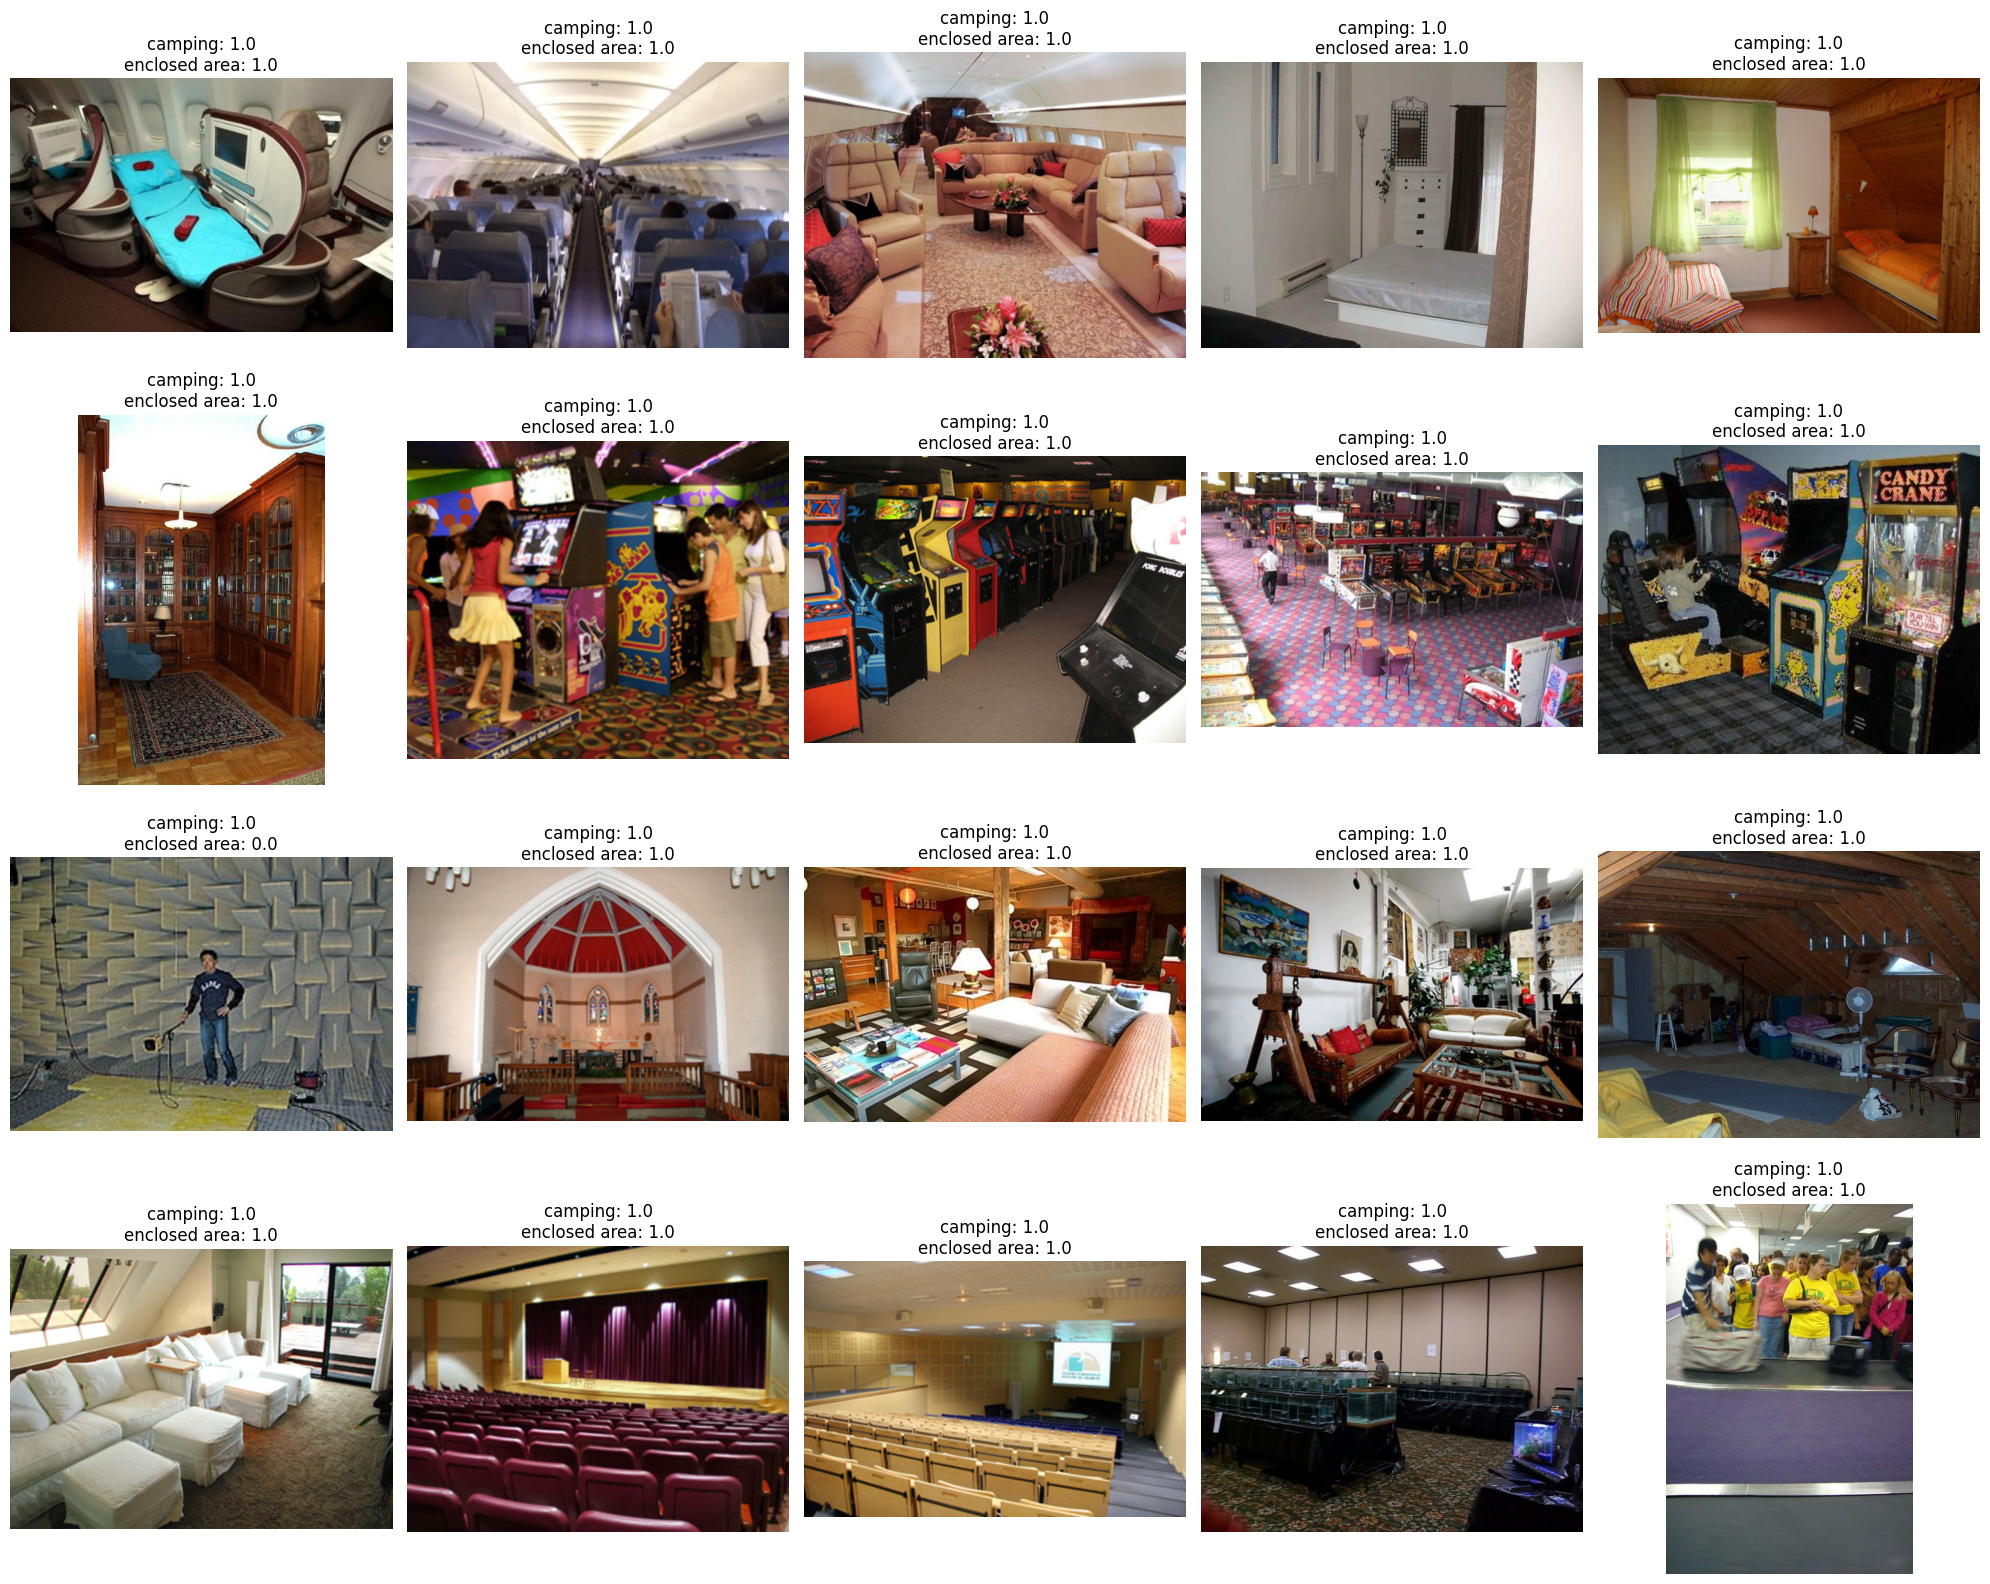

In [53]:
camping_samples = df_sun[df_sun['carpet'] == 1.0].head(20)

fig, axes = plt.subplots(4, 5, figsize=(20, 16))

for ax, (_, row) in zip(axes.flatten(), camping_samples.iterrows()):
    img_path = os.path.join('data/SUN/images/', row['file_path'])
    
    try:
        img = Image.open(img_path)
        ax.imshow(img)
        rock_stone_val = row['enclosed area']
        ax.set_title(f"camping: 1.0\nenclosed area: {rock_stone_val}")
    except Exception as e:
        ax.set_title("Brak pliku")
        
    ax.axis('off')

plt.tight_layout()
plt.show()